In [1]:
# Install required packages.
!pip install torch_geometric
!pip install torch torchvision torchaudio

# Import Dependencies
import torch
from torch.nn import Linear
import torch.nn.functional as F
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv, GCNConv
import numpy
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def print_versions() -> None:
    """
    Print the versions of PyTorch and PyG.
    """
    print(f"PyTorch v{torch.__version__}")
    print(f"PyG v{torch_geometric.__version__}")

print_versions()

PyTorch v2.1.1+cpu
PyG v2.4.0


# **1. Introduction**

# **2. Graph Dataset**

In [3]:
def load_planetoid(name: str) -> Planetoid:
    # Import dataset from PyTorch Geometric
    dataset = Planetoid(root=".", name=name)
    data = dataset[0]
    # Print information about the dataset
    print(f"Graph: {dataset[0]}")
    print(f"Number of graphs: {len(dataset)}")
    print(f"Number of nodes: {data.x.shape[0]}")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")
    print(f"Has isolated nodes: {data.has_isolated_nodes()}")

    # Calculate the number of samples in train, val, and test sets
    train_samples = int(data.train_mask.sum().item())
    val_samples = int(data.val_mask.sum().item())
    test_samples = int(data.test_mask.sum().item())

    print(f"Number of samples in the train set: {train_samples}")
    print(f"Number of samples in the validation set: {val_samples}")
    print(f"Number of samples in the test set: {test_samples}")  # tensor([False, False, False,  ...,  True,  True,  True])

    return dataset

## **CiteSeer**

CiteSeer stands on the stage with 3,327 scientific papers with each node having an exactly one of the 6 elite categories (class labels). Now, let's talk about data stats, where each paper/node in the CiteSeer universe is defined by a 3703-dimension word vector with 0/1 values.

ref:https://link.springer.com/chapter/10.1007/978-3-319-06028-6_26
https://docs.dgl.ai/en/0.8.x/generated/dgl.data.CiteseerGraphDataset.html

In [4]:
citeseer = load_planetoid(name='CiteSeer')

Processing...


Graph: Data(x=[3327, 3703], edge_index=[2, 9104], y=[3327], train_mask=[3327], val_mask=[3327], test_mask=[3327])
Number of graphs: 1
Number of nodes: 3327
Number of features: 3703
Number of classes: 6
Has isolated nodes: True
Number of samples in the train set: 120
Number of samples in the validation set: 500
Number of samples in the test set: 1000


Done!


**CiteSeers's Delights**


*   `x=[3327, 3703]` is the **node feature matrix**.  Picture this: there are 2708 documents and each one is represented with a 3703-dimension feature vector, all one hot encoded.
*   `edge_index=[2, 9104]` represents the **graph connectivity**. This tells who's hanging out with whom with a shape of (2, number of directed edges).
* `y=[3327]` is the **ground-truth labels**. Every node is assigned to one class


Statistics:

- Nodes: 3327

- Edges: 9228

- Number of Classes: 6

- Label Split:

- Train: 120

- Valid: 500

- Test: 1000

In [5]:
print(f"Directed: {citeseer[0].is_directed()}")
print(f"Isolated Nodes: {citeseer[0].has_isolated_nodes()}")
print(f"Has Self Loops: {citeseer[0].has_self_loops()}")

Directed: False
Isolated Nodes: True
Has Self Loops: False


<BarContainer object of 32 artists>

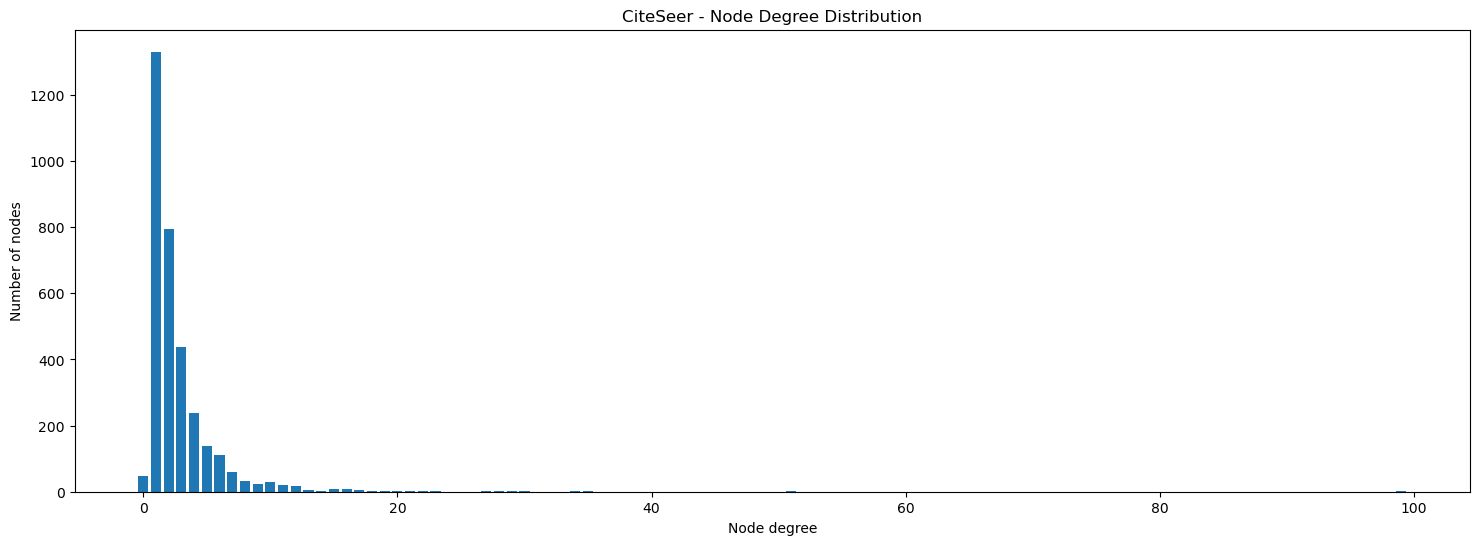

In [6]:
# Node degree distribution

node_degrees = torch_geometric.utils.degree(citeseer.edge_index[0]).numpy()
node_degrees = Counter(node_degrees)  # convertt to a dictionary object

# Bar plot
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
ax.set_title('CiteSeer - Node Degree Distribution')
plt.bar(node_degrees.keys(),
        node_degrees.values())

CiteSeer has a majority of nodes with 1 or 2 neighbors. Now you might be thinking, "What's the big deal?". Well, let me tell you, it would be like hosting a party with just a couple of friends - its cozy, but there is no rave. The global information about their conneections to the community is gonna be lacking.






** Defining the Mission: Node Classification Task **

Our mission is now crystal clear: armed with node feature representations of each node and their connections to their neighboring nodes, we are on a quest to to predict the correct class label for each and every node in the given graph.

Note: we are not only relying on the surface-level node feature matrix but are diving deep into the data fabric, analyzing every interaction, and decuphering every whisper. Its more about understanding the dataset than make simple raw predictions based on patterns.





# **3. Create Model**

In [7]:
# Base GNN Module

class BaseGNN(torch.nn.Module):
    """
    Base class for Graph Neural Network models.
    """

    def __init__(
        self,
    ):
        super().__init__()
        torch.manual_seed(48)
        # Initialize lists to store animation-related statistics
        self._init_animate_stats()
        self.optimizer = None

    def _init_animate_stats(self) -> None:
        """Initialize animation-related statistics."""
        self.embeddings = []
        self.losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.predictions = []

    def _update_animate_stats(
        self,
        embedding: torch.Tensor,
        loss: torch.Tensor,
        train_accuracy: float,
        val_accuracy: float,
        prediction: torch.Tensor,
    ) -> None:
        # Update animation-related statistics with new data
        self.embeddings.append(embedding)
        self.losses.append(loss)
        self.train_accuracies.append(train_accuracy)
        self.val_accuracies.append(val_accuracy)
        self.predictions.append(prediction)

    def accuracy(self, pred_y: torch.Tensor, y: torch.Tensor) -> float:
        """
        Calculate accuracy between predicted and true labels.

        :param pred (torch.Tensor): Predicted labels.
        :param y (torch.Tensor): True labels.

        :returns: Accuracy value.
        """
        return ((pred_y == y).sum() / len(y)).item()

    def fit(self, data: Data, epochs: int) -> None:
        """
        Train the GNN model on the provided data.

        :param data: The dataset to use for training.
        :param epochs: Number of training epochs.
        """
        # Use CrossEntropyLoss as the criterion for training
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = self.optimizer

        self.train()
        for epoch in range(epochs + 1):
            # Training
            optimizer.zero_grad()
            _, out = self(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = self.accuracy(
                out[data.train_mask].argmax(dim=1), data.y[data.train_mask]
            )
            loss.backward()
            optimizer.step()

            # Validation
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = self.accuracy(
                out[data.val_mask].argmax(dim=1), data.y[data.val_mask]
            )
            kwargs = {
                "embedding": out.detach().cpu().numpy(),
                "loss": loss.detach().cpu().numpy(),
                "train_accuracy": acc,
                "val_accuracy": val_acc,
                "prediction": out.argmax(dim=1).detach().cpu().numpy(),
            }

            # Update animation-related statistics
            self._update_animate_stats(**kwargs)
            # Print metrics every 10 epochs
            if epoch % 25 == 0:
                print(
                    f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: "
                    f"{acc * 100:>6.2f}% | Val Loss: {val_loss:.2f} | "
                    f"Val Acc: {val_acc * 100:.2f}%"
                )

    @torch.no_grad()
    def test(self, data: Data) -> float:
        """
        Evaluate the model on the test set and return the accuracy score.

        :param data: The dataset to use for testing.
        :return: Test accuracy.
        """
        # Set the model to evaluation mode
        self.eval()
        _, out = self(data.x, data.edge_index)
        acc = self.accuracy(
            out.argmax(dim=1)[data.test_mask], data.y[data.test_mask]
        )
        return acc

In [8]:
class MLP(torch.nn.Module):
    """
    Our MLP is defined by two linear layers and enhanced by ReLU
    non-linearity  and dropout. Here, we first reduce the input dimension
    feature vector to a low-dimensional embedding (hidden_dim),
    while the second linear layer acts as a classifier that should map  each
    low-dimensional node embedding to one of class labels.

    """

    def __init__(self, input_dim: int, hidden_dim: int, out_dim: int):
        """
        Initialize the MLP model.

        Parameters:
            input_dim (int): Dimensionality of input features.
            hidden_dim (int): Dimensionality of the hidden layer.
            out_dim (int): Dimensionality of the output layer.
        """
        super().__init__()
        torch.manual_seed(48)
        # Initialize lists to store animation-related statistics
        self._init_animate_stats()

        # Define two linear layers
        self.lin1 = Linear(input_dim, hidden_dim)
        self.lin2 = Linear(hidden_dim, out_dim)

        # Initialize the optimizer
        self.optimizer = torch.optim.Adam(
            self.parameters(), lr=0.01, weight_decay=5e-4
        )

    def _init_animate_stats(self):
        """Initialize animation-related statistics."""
        self.embeddings = []
        self.losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.predictions = []

    def _update_animate_stats(
        self,
        embedding: torch.Tensor,
        loss: torch.Tensor,
        train_accuracy: float,
        val_accuracy: float,
        prediction: torch.Tensor,
    ):
        """
        Update animation-related statistics.

        :param embedding (torch.Tensor): Node Latent Representations.
        :param loss (torch.Tensor): Training loss.
        :param train_accuracy (float): Training accuracy.
        :param val_accuracy (float): Validation accuracy.
        :param prediction (torch.Tensor): Model predictions for the whole graph.
        """
        """Update animation-related statistics."""
        self.embeddings.append(embedding)
        self.losses.append(loss)
        self.train_accuracies.append(train_accuracy)
        self.val_accuracies.append(val_accuracy)
        self.predictions.append(prediction)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the MLP model.

        :param (torch.Tensor): Input feature tensor.
        :returns torch.Tensor: Output tensor.
        """
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

    @staticmethod
    def accuracy(pred: torch.Tensor, y: torch.Tensor) -> float:
        """
        Calculate accuracy between predicted and true labels.

        :param pred (torch.Tensor): Predicted labels.
        :param y (torch.Tensor): True labels.

        :returns: Accuracy value.
        """
        return ((pred == y).sum() / len(y)).item()

    def fit(self, data: Data, epochs: int) -> None:
        """
        Train the MLP model.

        :param data: The dataset to use for training.
        :param epochs: Number of training epochs.
        """

        criterion = torch.nn.CrossEntropyLoss()
        optimizer = self.optimizer

        self.train()
        for epoch in range(epochs + 1):
            # Training
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = self.accuracy(
                out[data.train_mask].argmax(dim=1), data.y[data.train_mask]
            )
            loss.backward()
            optimizer.step()

            # Validation
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = self.accuracy(
                out[data.val_mask].argmax(dim=1), data.y[data.val_mask]
            )

            kwargs = {
                "embedding": out.detach().cpu().numpy(),
                "loss": loss.detach().cpu().numpy(),
                "train_accuracy": acc,
                "val_accuracy": val_acc,
                "prediction": out.argmax(dim=1).detach().cpu().numpy(),
            }

            self._update_animate_stats(**kwargs)

            # Print metrics every 10 epochs
            if epoch % 25 == 0:
                print(
                    f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: "
                    f"{acc * 100:>6.2f}% | Val Loss: {val_loss:.2f} | "
                    f"Val Acc: {val_acc * 100:.2f}%"
                )

    @torch.no_grad()
    def test(self, data):
        """
        Evaluate the MLP model on the test set.

        :param data: The dataset to use for testing.
        :return: Test accuracy.
        """
        self.eval()
        out = self(data.x)
        acc = self.accuracy(
            out.argmax(dim=1)[data.test_mask], data.y[data.test_mask]
        )
        return acc

In [9]:
class GCN(BaseGNN):
    """
    Graph Convolutional Network model for node classification.
    """

    def __init__(
        self, input_dim: int, hidden_dim: int, output_dim: int
    ):
        super().__init__()
        self.gcn1 = GCNConv(input_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, output_dim)
        self.optimizer = torch.optim.Adam(
            self.parameters(), lr=0.01, weight_decay=5e-4
        )

    def forward(
        self, x: torch.Tensor, edge_index: torch.Tensor
    ) -> torch.Tensor:
        """
        Forward pass of the Graph Convolutional Network model.

        :param (torch.Tensor): Input feature tensor.
        :param (torch.Tensor): Graph connectivity information
        :returns torch.Tensor: Output tensor.
        """
        h = F.dropout(x, p=0.5, training=self.training)
        h = self.gcn1(h, edge_index).relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn2(h, edge_index)
        return h, F.log_softmax(h, dim=1)

In [10]:
class GAT(BaseGNN):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 heads: int=8):
        super().__init__()
        torch.manual_seed(48)
        self.gcn1 = GATConv(input_dim, hidden_dim, heads=heads)
        self.gcn2 = GATConv(hidden_dim * heads, output_dim, heads=1)
        self.optimizer = torch.optim.Adam(
            self.parameters(), lr=0.01, weight_decay=5e-4
        )

    def forward(
            self, x: torch.Tensor, edge_index: torch.Tensor
    ) -> torch.Tensor:
        """
        Forward pass of the Graph Convolutional Network model.

        :param (torch.Tensor): Input feature tensor.
        :param (torch.Tensor): Graph connectivity information
        :returns torch.Tensor: Output tensor.
        """
        h = F.dropout(x, p=0.6, training=self.training)
        h = self.gcn1(h, edge_index).relu()
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.gcn2(h, edge_index).relu()
        return h, F.log_softmax(h, dim=1)

# **4. Model Training**

In [11]:
def train_and_test_model(model, data: Data, num_epochs: int) -> tuple:
    """
    Train and test a given model on the provided data.

    :param model: The PyTorch model to train and test.
    :param data: The dataset to use for training and testing.
    :param num_epochs: Number of training epochs.
    :return: A tuple containing the trained model and the test accuracy.
    """
    model.fit(data, num_epochs)
    test_acc = model.test(data)
    return model, test_acc

In [12]:
num_epochs=100
data = citeseer[0]

mlp = MLP(
    input_dim=citeseer.num_features,
    hidden_dim=16,
    out_dim=citeseer.num_classes,
)


gcn = GCN(
    input_dim=citeseer.num_features,
    hidden_dim=16,
    output_dim=citeseer.num_classes,
)

gat = GAT(
    input_dim=citeseer.num_features,
    hidden_dim=8,
    output_dim=citeseer.num_classes,
    heads=6,
)

print(f"{mlp}\n", f"-"*88)
mlp, test_acc_mlp = train_and_test_model(mlp, data, num_epochs)
print(f"-"*88)
print(f"\nTest accuracy: {test_acc_mlp * 100:.2f}%\n")


print(f"{gcn}\n", f"-"*88)
gcn, test_acc_gcn = train_and_test_model(gcn, data, num_epochs)
print(f"-"*88)
print(f"\nTest accuracy: {test_acc_gcn * 100:.2f}%\n")

print(f"{gat}\n", f"-"*88)
gat, test_acc_gat = train_and_test_model(gat, data, num_epochs)
print(f"-"*88)
print(f"\nTest accuracy: {test_acc_gat * 100:.2f}%\n")

MLP(
  (lin1): Linear(in_features=3703, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=6, bias=True)
)
 ----------------------------------------------------------------------------------------
Epoch   0 | Train Loss: 1.799 | Train Acc:  16.67% | Val Loss: 1.80 | Val Acc: 14.40%
Epoch  25 | Train Loss: 0.270 | Train Acc:  90.83% | Val Loss: 1.96 | Val Acc: 34.00%
Epoch  50 | Train Loss: 0.119 | Train Acc:  95.00% | Val Loss: 2.21 | Val Acc: 38.00%
Epoch  75 | Train Loss: 0.134 | Train Acc:  94.17% | Val Loss: 2.17 | Val Acc: 39.20%
Epoch 100 | Train Loss: 0.155 | Train Acc:  93.33% | Val Loss: 2.17 | Val Acc: 41.20%
----------------------------------------------------------------------------------------

Test accuracy: 51.40%

GCN(
  (gcn1): GCNConv(3703, 16)
  (gcn2): GCNConv(16, 6)
)
 ----------------------------------------------------------------------------------------
Epoch   0 | Train Loss: 1.803 | Train Acc:  16.67% | Val Loss: 1.80 | Val Acc: 17.60%
E

In [13]:
print("MLP Structure:")
print(mlp)

print("\nGCN Structure:")
print(gcn)

print("\nGAT Structure:")
print(gat)

MLP Structure:
MLP(
  (lin1): Linear(in_features=3703, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=6, bias=True)
)

GCN Structure:
GCN(
  (gcn1): GCNConv(3703, 16)
  (gcn2): GCNConv(16, 6)
)

GAT Structure:
GAT(
  (gcn1): GATConv(3703, 8, heads=6)
  (gcn2): GATConv(48, 6, heads=1)
)


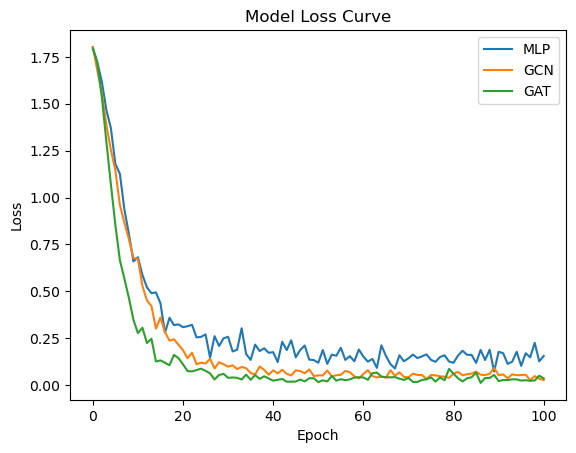

In [14]:
# Plotting the losses
plt.plot(mlp.losses, label='MLP')
plt.plot(gcn.losses, label='GCN')
plt.plot(gat.losses, label='GAT')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Curve')
plt.legend()
plt.show()

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns


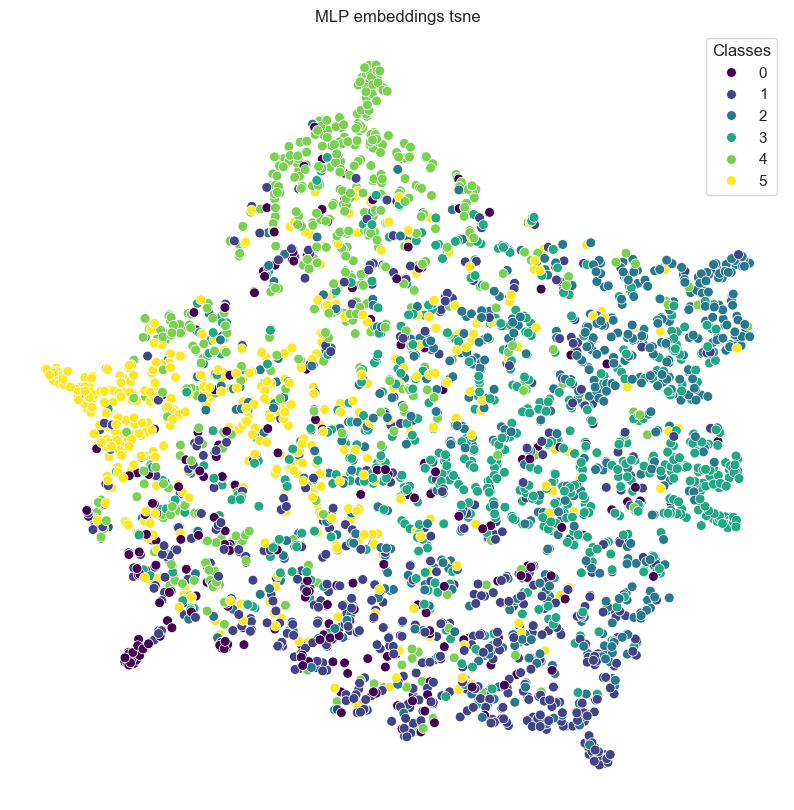

In [16]:
# Get embeddings
embeddings = mlp(citeseer[0].x)

# Train TSNE
tsne = TSNE(n_components=2, learning_rate='auto',
            init='pca').fit_transform(embeddings.detach())

# Set the Seaborn theme
sns.set_theme(style="whitegrid")

# Get the class labels
class_labels = citeseer[0].y.cpu().numpy()

# Plot TSNE with legend
plt.figure(figsize=(10, 10))
plt.axis('off')
scatterplot = sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=class_labels, palette="viridis", s=50)
scatterplot.legend(title='Classes')
plt.title("MLP embeddings tsne")
plt.show()

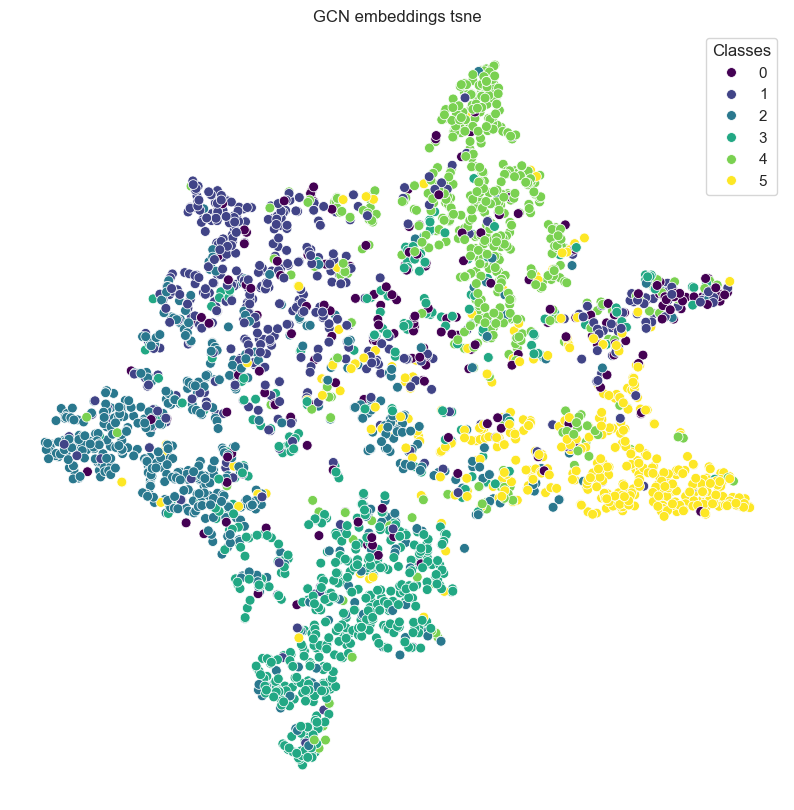

In [17]:

# Get embeddings
embeddings, _ = gcn(citeseer[0].x, citeseer[0].edge_index)

# Train TSNE
tsne = TSNE(n_components=2, learning_rate='auto',
            init='pca').fit_transform(embeddings.detach())

# Set the Seaborn theme
sns.set_theme(style="whitegrid")

# Get the class labels
class_labels = citeseer[0].y.cpu().numpy()

# Plot TSNE with legend
plt.figure(figsize=(10, 10))
plt.axis('off')
scatterplot = sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=class_labels, palette="viridis", s=50)
scatterplot.legend(title='Classes')
plt.title("GCN embeddings tsne")
plt.show()

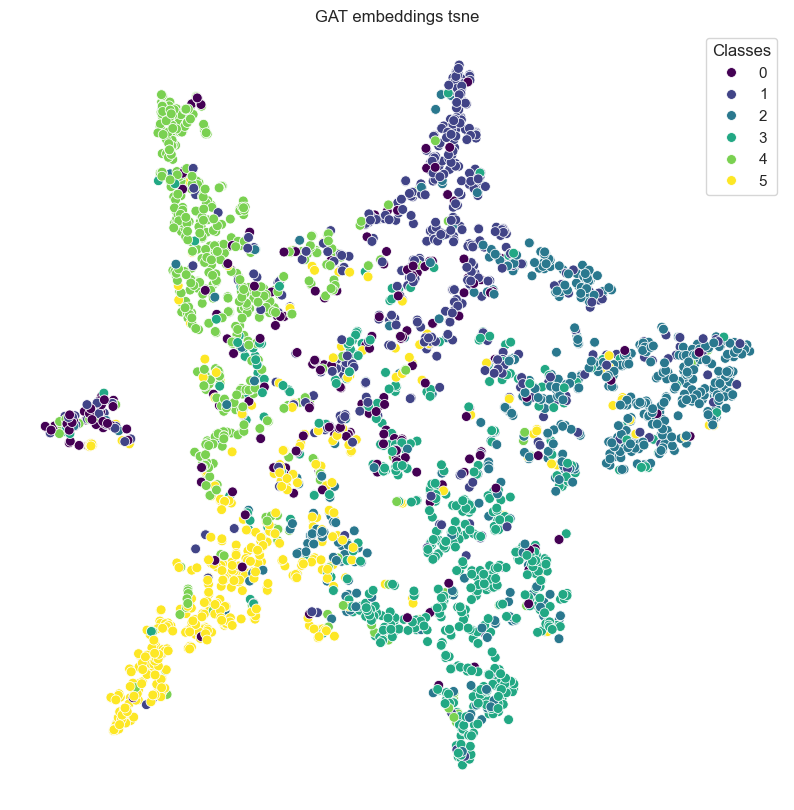

In [18]:

# Get embeddings
embeddings, _ = gat(citeseer[0].x, citeseer[0].edge_index)

# Train TSNE
tsne = TSNE(n_components=2, learning_rate='auto',
            init='pca').fit_transform(embeddings.detach())

# Get the class labels
class_labels = citeseer[0].y.cpu().numpy()

# Plot TSNE with legend
plt.figure(figsize=(10, 10))
plt.axis('off')
scatterplot = sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=class_labels, palette="viridis", s=50)
scatterplot.legend(title='Classes')
plt.title("GAT embeddings tsne")
plt.show()

In [19]:
citeseer[0].y

tensor([3, 1, 5,  ..., 3, 1, 5])

In [20]:
# # Exploring the effect of dim of hidden layer
# mlp_hidden_dims = [8, 16, 32, 64]
# gcn_hidden_dims = [8, 16, 32, 64]
# gat_hidden_dims = [8, 16, 32, 64]

# for hidden_dim in mlp_hidden_dims:
#     mlp = MLP(
#         input_dim=citeseer.num_features,
#         hidden_dim=hidden_dim,
#         out_dim=citeseer.num_classes,
#     )
#     print(f"MLP Hidden Dim: {hidden_dim}\n", f"-"*88)
#     mlp, test_acc_mlp = train_and_test_model(mlp, data, num_epochs)
#     print(f"-"*88)
#     print(f"\nTest accuracy (MLP): {test_acc_mlp * 100:.2f}%\n")

# for hidden_dim in gcn_hidden_dims:
#     gcn = GCN(
#         input_dim=citeseer.num_features,
#         hidden_dim=hidden_dim,
#         output_dim=citeseer.num_classes,
#     )
#     print(f"GCN Hidden Dim: {hidden_dim}\n", f"-"*88)
#     gcn, test_acc_gcn = train_and_test_model(gcn, data, num_epochs)
#     print(f"-"*88)
#     print(f"\nTest accuracy (GCN): {test_acc_gcn * 100:.2f}%\n")

# for hidden_dim in gat_hidden_dims:
#     gat = GAT(
#         input_dim=citeseer.num_features,
#         hidden_dim=hidden_dim,
#         output_dim=citeseer.num_classes,
#         heads=6,
#     )
#     print(f"GAT Hidden Dim: {hidden_dim}\n", f"-"*88)
#     gat, test_acc_gat = train_and_test_model(gat, data, num_epochs)
#     print(f"-"*88)
#     print(f"\nTest accuracy (GAT): {test_acc_gat * 100:.2f}%\n")

# Conclusion

Based on the information given, we can conclude the following:

- The GAT model shows the best performance using the same hidden layer dimensions (16). It achieved 68.20% accuracy on the test set, which is better than the MLP and GCN models with 52.00% and 66.70% accuracy respectively.

- The MLP model had the worst performance with its accuracy of 52.00% on the test set. This may be due to the fact that the MLP model can only consider the feature information of the nodes and cannot utilize the graph structure information.

- The GCN model shows a significant performance improvement over the MLP model on the test set, achieving an accuracy of 66.70%.The GCN model is able to utilize the information of the neighboring nodes, which results in a better capture of the relationships in the graph structure.

- The GAT model showed the best performance on the test set achieving 68.20% accuracy.The GAT model uses an attention mechanism and is able to adaptively learn the importance between nodes and capitalize on the relationships in the graph structure.

- The GCN and GAT models achieved faster convergence within the same number of training rounds relative to the MLP model. This may be due to the ability of the GCN and GAT models to utilize the graph structure information to improve the prediction performance by propagating information between nodes. Compared to the MLP model, the GCN and GAT models are able to make better use of the information of neighboring nodes during the training process, which leads to faster learning of useful representations.